# mGPLVM analysis on recurrent units

In [1]:
%load_ext autoreload
%autoreload 2
import os
import pickle
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import torch
from sklearn.linear_model import RidgeCV

import mgplvm as mgp
import utils as utils
from utils.path_settings import *


plt.rcParams['figure.titlesize'] = 12
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.handlelength'] = 1.5
plt.rcParams['legend.handleheight'] = 0.5
plt.rcParams['axes.spines.right'] = False
plt.rcParams[('axes.spines.top')] = False
device = mgp.utils.get_device()
torch.set_default_dtype(torch.float64)

loading
/home/timmy/nonnormal/dummy/mental-rotations


2025-05-20 13:10:42.026127: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-20 13:10:42.046517: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-20 13:10:42.074799: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-20 13:10:42.074852: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-20 13:10:42.093248: I tensorflow/core/platform/cpu_feature_gua

In [2]:
def plot_activity_heatmap(Y):
  ### plot the activity of our neurons ###
  plt.figure(figsize = (12, 6))
  plt.imshow(Y[0, ...], cmap = 'Greys', aspect = 'auto', vmin = np.quantile(Y, 0.01), vmax = np.quantile(Y, 0.99))
  plt.xlabel('time')
  plt.ylabel('neuron')
  plt.title('Raw activity', fontsize = 25)
  plt.xticks([])
  plt.yticks([])
  plt.show()

def plot_tuning_curves(fit_thetas, ys_noise, plot_thetas, ys, ys_lin, ys_bins, ys_gp, xs_bins):
  plt.figure(figsize = (5,3.0))
  plt.scatter(fit_thetas, ys_noise, color = "k", alpha = 0.2)
  plt.plot(plot_thetas, ys, 'k-')
  plt.plot(plot_thetas, ys_lin, 'b-')
  plt.plot(xs_bins, ys_bins, 'g-')
  plt.plot(plot_thetas, ys_gp, 'm-')
  plt.legend(['true', 'linear', 'binned', 'GP'], frameon = False, ncol = 2, loc = 'upper center', bbox_to_anchor = [0.5, 1.4])
  plt.xlim(-np.pi, np.pi)
  plt.xlabel('theta')
  plt.ylabel('activity')
  plt.yticks([])
  plt.xticks([-np.pi, 0, np.pi], [r'$-\pi$', r'$0$', r'$\pi$'])
  plt.show()

def cb(mod, i, loss):
  """here we construct an (optional) function that helps us keep track of the training"""
  if i in [0, 50, 100, 150, 300, 500, 1000, 1500, 1999]: #iterations to plot
    X = mod.lat_dist.prms[0].detach().cpu().numpy()[0, ...]
    X = X % (2*np.pi)
    plt.figure(figsize = (4,4))
    plt.xlim(0, 2*np.pi); plt.ylim(0, 2*np.pi)
    plt.xlabel("true latents"); plt.ylabel("model latents")
    plt.scatter(thetas_plot, X[:, 0], color = 'k')
    plt.title('iter = '+str(i))
    plt.show()
    print(mod.lat_dist.msg(Y, None, None) + mod.svgp.msg + mod.lprior.msg, loss/n_ts1)

def plot_final_thetas(thetas2, thetas2_lin, thetas2_mgplvm):
  plt.figure()
  plt.scatter(thetas2, thetas2_lin, color = "b")
  plt.scatter(thetas2, thetas2_mgplvm, color = "k")
  plt.legend(['linear', 'mgplvm'], frameon = False, ncol = 2, loc = 'upper center', bbox_to_anchor = (0.5, 1.25))
  plt.xlabel('true theta')
  plt.ylabel('predicted theta')
  plt.show()

def plot_final_errors(errs_lin, errs_mgplvm, bins):
  plt.figure()
  plt.hist(errs_lin, bins = bins, color = 'b', alpha = 0.2)
  plt.hist(errs_mgplvm, bins = bins, color = 'k', alpha = 0.2)
  plt.axvline(np.mean(errs_lin), color = 'b', lw = 3)
  plt.axvline(np.mean(errs_mgplvm), color = 'k', lw = 3)
  plt.xlabel('error')
  plt.ylabel('frequency')
  plt.legend(['linear', 'mgplvm'], frameon = False)
  plt.show()

def plot_uncertainty_estimates(xs, errs_by_uncertainty):
  #xs, errs_by_uncertainty = xs**2, errs_by_uncertainty**2 #variances instead of stds
  plt.figure(figsize = (5,5))
  plt.scatter(xs, errs_by_uncertainty, color = "k")
  plt.plot([xs[0], xs[-1]], [xs[0], xs[-1]], "k-")
  plt.xlabel("uncertainty")
  plt.ylabel("RMSE")
  plt.xticks([0.15, 0.20, 0.25])
  plt.yticks([0.15, 0.20, 0.25])
  plt.show()

In [3]:
neural_activations = torch.load("/home/timmy/storage/mental_rotations/saved_datasets/network_activity.pt")

In [3]:
neural_activations.shape

torch.Size([4096, 20, 675])

## Destroy temporal structure for now and see where unsupervised neural tuning gets us

Credit: Kris's [Colab Notebook](https://colab.research.google.com/drive/1C7x5u4cMsH5f4i261Yz81zgDHgcJ-_MY?usp=sharing#scrollTo=_kLWsteXAb5z)

In [32]:
# subsample the conditions
m = 100
n = 50
subsampling_index_1 = torch.randperm(neural_activations.shape[0])[:m]
subsampling_index_2 = torch.randperm(neural_activations.shape[-1])[:n]
neural_activations_subsampled = neural_activations.reshape(-1, neural_activations.shape[-1])[subsampling_index_1][:, subsampling_index_2]
print(f"subsampled to shape {neural_activations_subsampled.shape}")
m, n = neural_activations_subsampled.shape
neural_activations_subsampled = neural_activations_subsampled.unsqueeze(0).permute(0, 2, 1).cpu().detach()

subsampled to shape torch.Size([100, 50])


In [33]:
subsampling_index_2

tensor([571, 577, 646, 654, 543, 420, 347,  98,   1, 670, 162, 119, 522, 517,
        413, 244, 246,  42,  57, 255, 548, 248, 265, 603, 542,  66, 120, 581,
        495, 635, 641, 515, 210,  60, 331, 437, 100,  32, 243, 426,   9, 416,
        405, 560, 163, 239, 353, 249, 285, 135])

In [104]:
d = 2 # 2 for now; maybe try 3 later
m = 100
n = 50
def build_model(): 
    manif = mgp.manifolds.Torus(m, d)
    lat_dist = mgp.rdist.ReLie(manif, m, n_samples=1)
    kernel = mgp.kernels.QuadExp(n, manif.distance)
    lik = mgp.likelihoods.Gaussian(n)
    lprior = mgp.lpriors.Uniform(manif)
    z = manif.inducing_points(n, 50)
    model = mgp.models.SvgpLvm(
        n, m, 1, z, kernel, lik, lat_dist, lprior, whiten = True
    )
    return model


model = build_model()

In [ ]:

train_opts = {
    "lrate": 5e-2,
    "max_steps": 1000,
    "n_mc": 64,
    "print_every": 10,
    "burnin": 30 / 5e-2,
    "optimizer": torch.optim.Adam,
}

# train model
progress = mgp.optimisers.svgp.fit(neural_activations_subsampled, model, **train_opts)

iter   0 | elbo -6.472 | kl  0.004 | loss  6.472 | |mu| 0.111 | sig 1.500 | scale 1.000 | ell 2.000 | lik_sig 1.000 |
iter  10 | elbo -2.526 | kl  0.004 | loss  2.526 | |mu| 0.098 | sig 1.498 | scale 1.000 | ell 1.999 | lik_sig 1.001 |
iter  20 | elbo -1.991 | kl  0.005 | loss  1.991 | |mu| 0.181 | sig 1.492 | scale 0.999 | ell 2.001 | lik_sig 1.003 |
iter  30 | elbo -1.817 | kl  0.005 | loss  1.817 | |mu| 0.282 | sig 1.484 | scale 0.998 | ell 2.005 | lik_sig 1.006 |
iter  40 | elbo -1.735 | kl  0.005 | loss  1.735 | |mu| 0.465 | sig 1.474 | scale 0.998 | ell 2.009 | lik_sig 1.007 |
iter  50 | elbo -1.675 | kl  0.005 | loss  1.675 | |mu| 0.815 | sig 1.459 | scale 0.997 | ell 2.013 | lik_sig 1.009 |
iter  60 | elbo -1.625 | kl  0.005 | loss  1.626 | |mu| 1.214 | sig 1.436 | scale 0.996 | ell 2.016 | lik_sig 1.010 |
iter  70 | elbo -1.583 | kl  0.006 | loss  1.584 | |mu| 1.396 | sig 1.401 | scale 0.996 | ell 2.018 | lik_sig 1.010 |
iter  80 | elbo -1.560 | kl  0.006 | loss  1.561 | |mu| 

KeyboardInterrupt: 

In [105]:
model.load_state_dict(torch.load("/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_unsupervised_t2.pt"))
indices = torch.load("/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_unsupervised_t2_indices.pt")

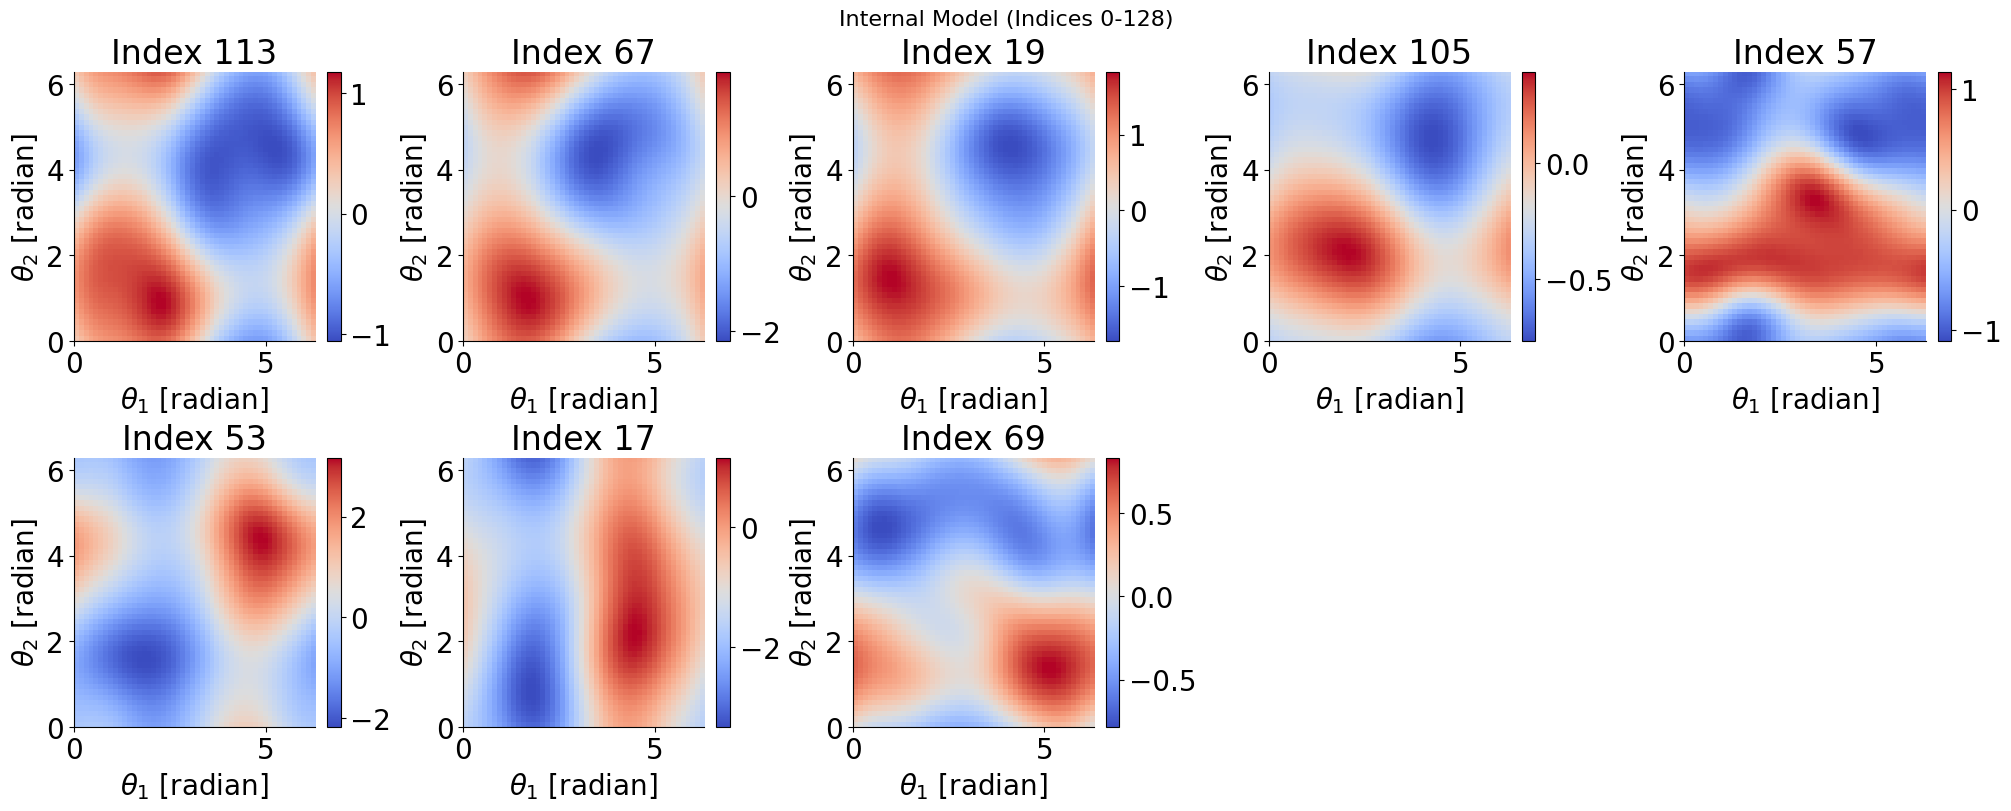

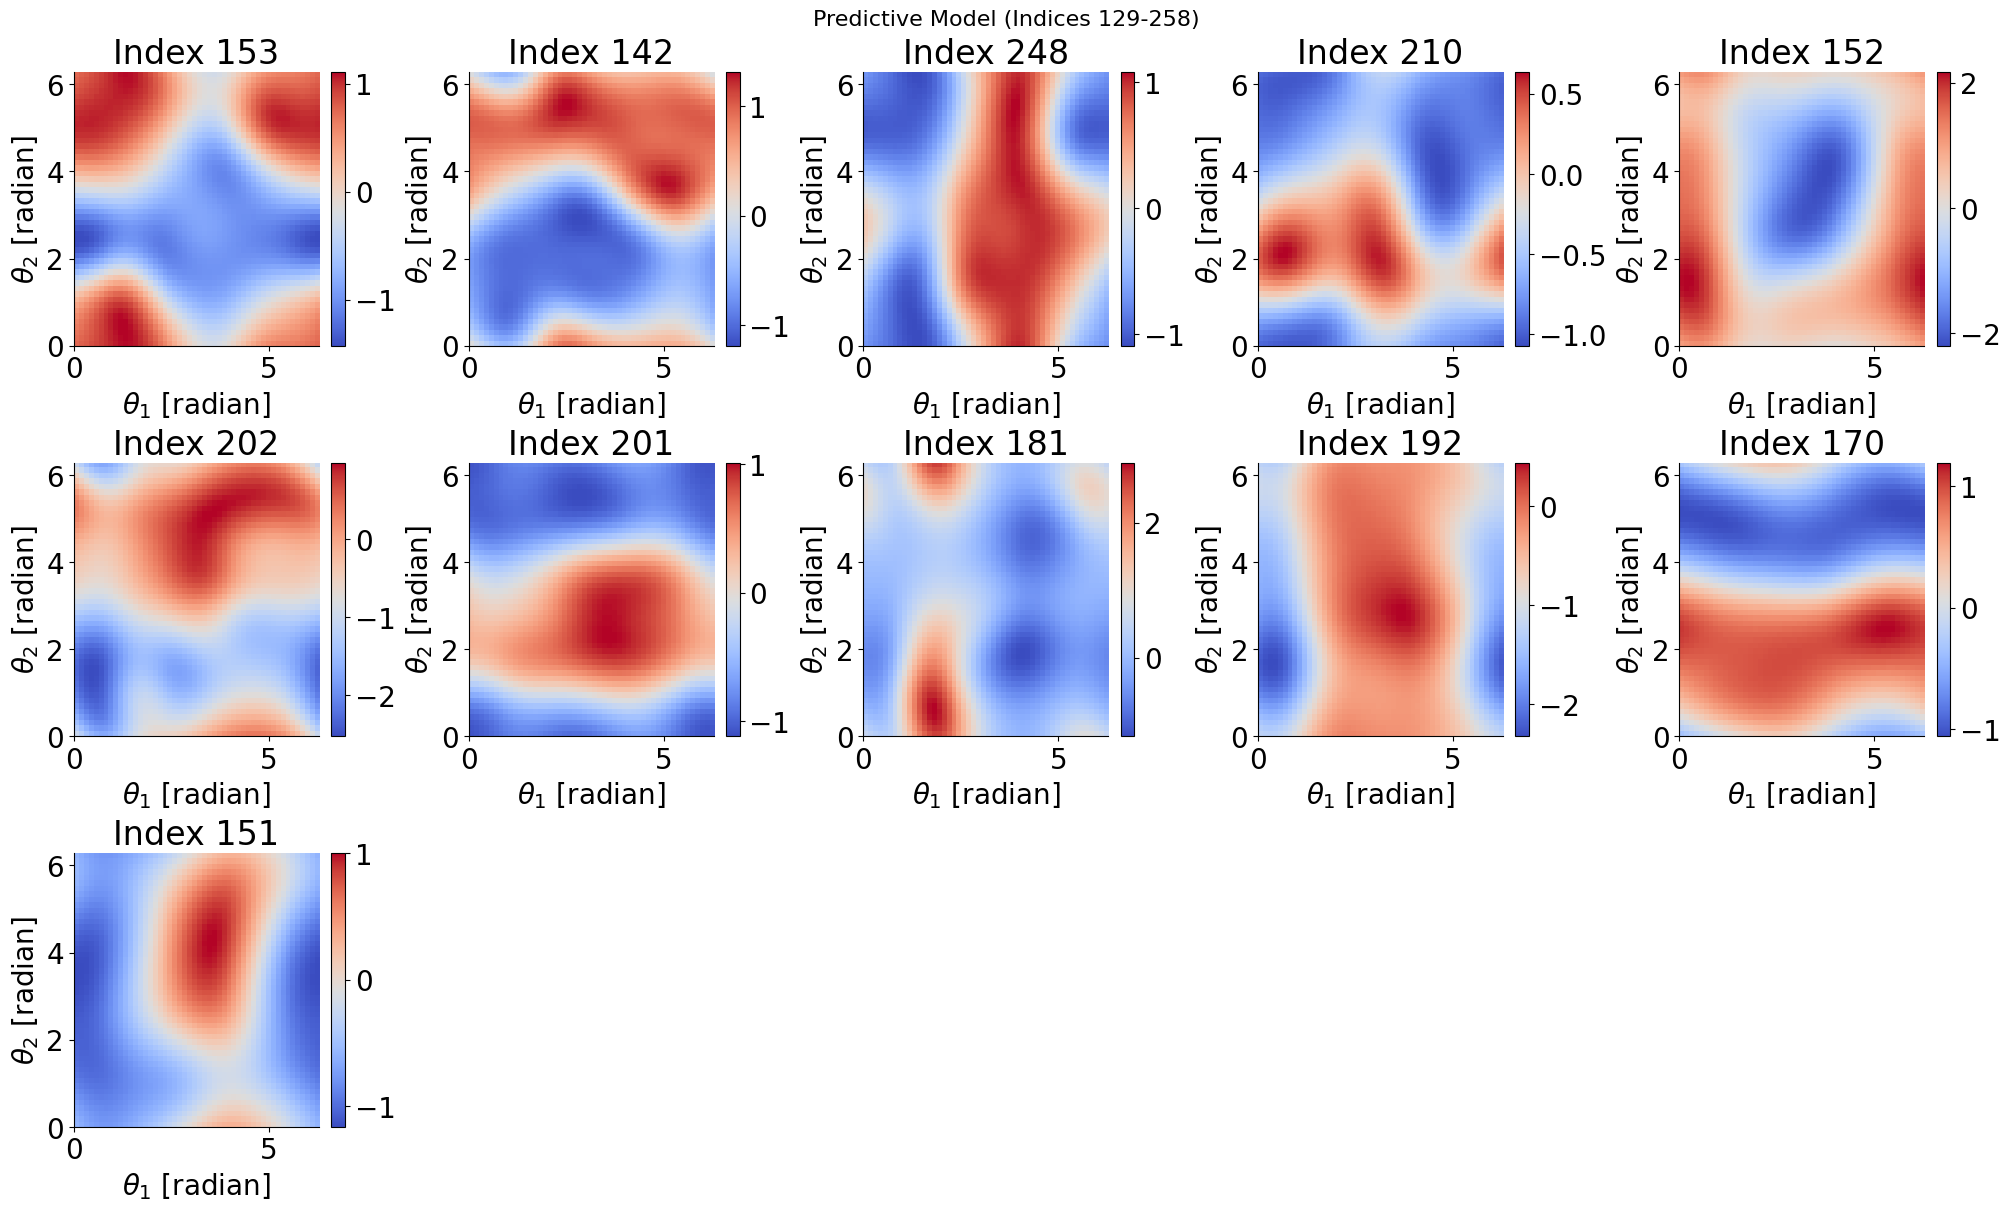

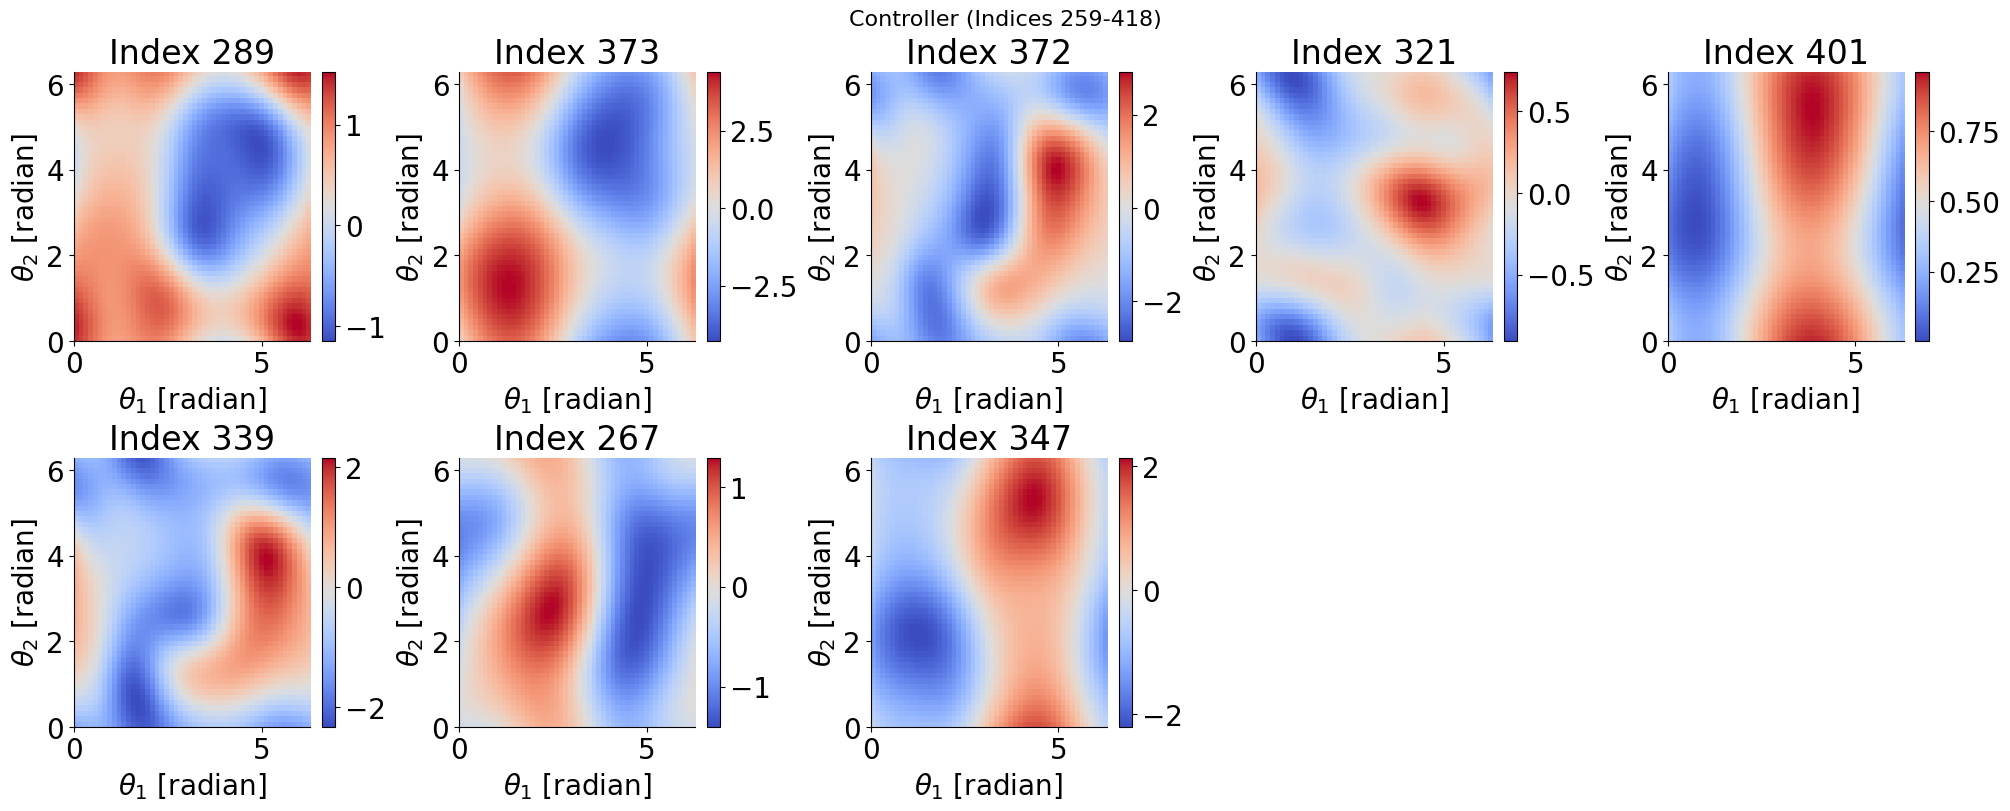

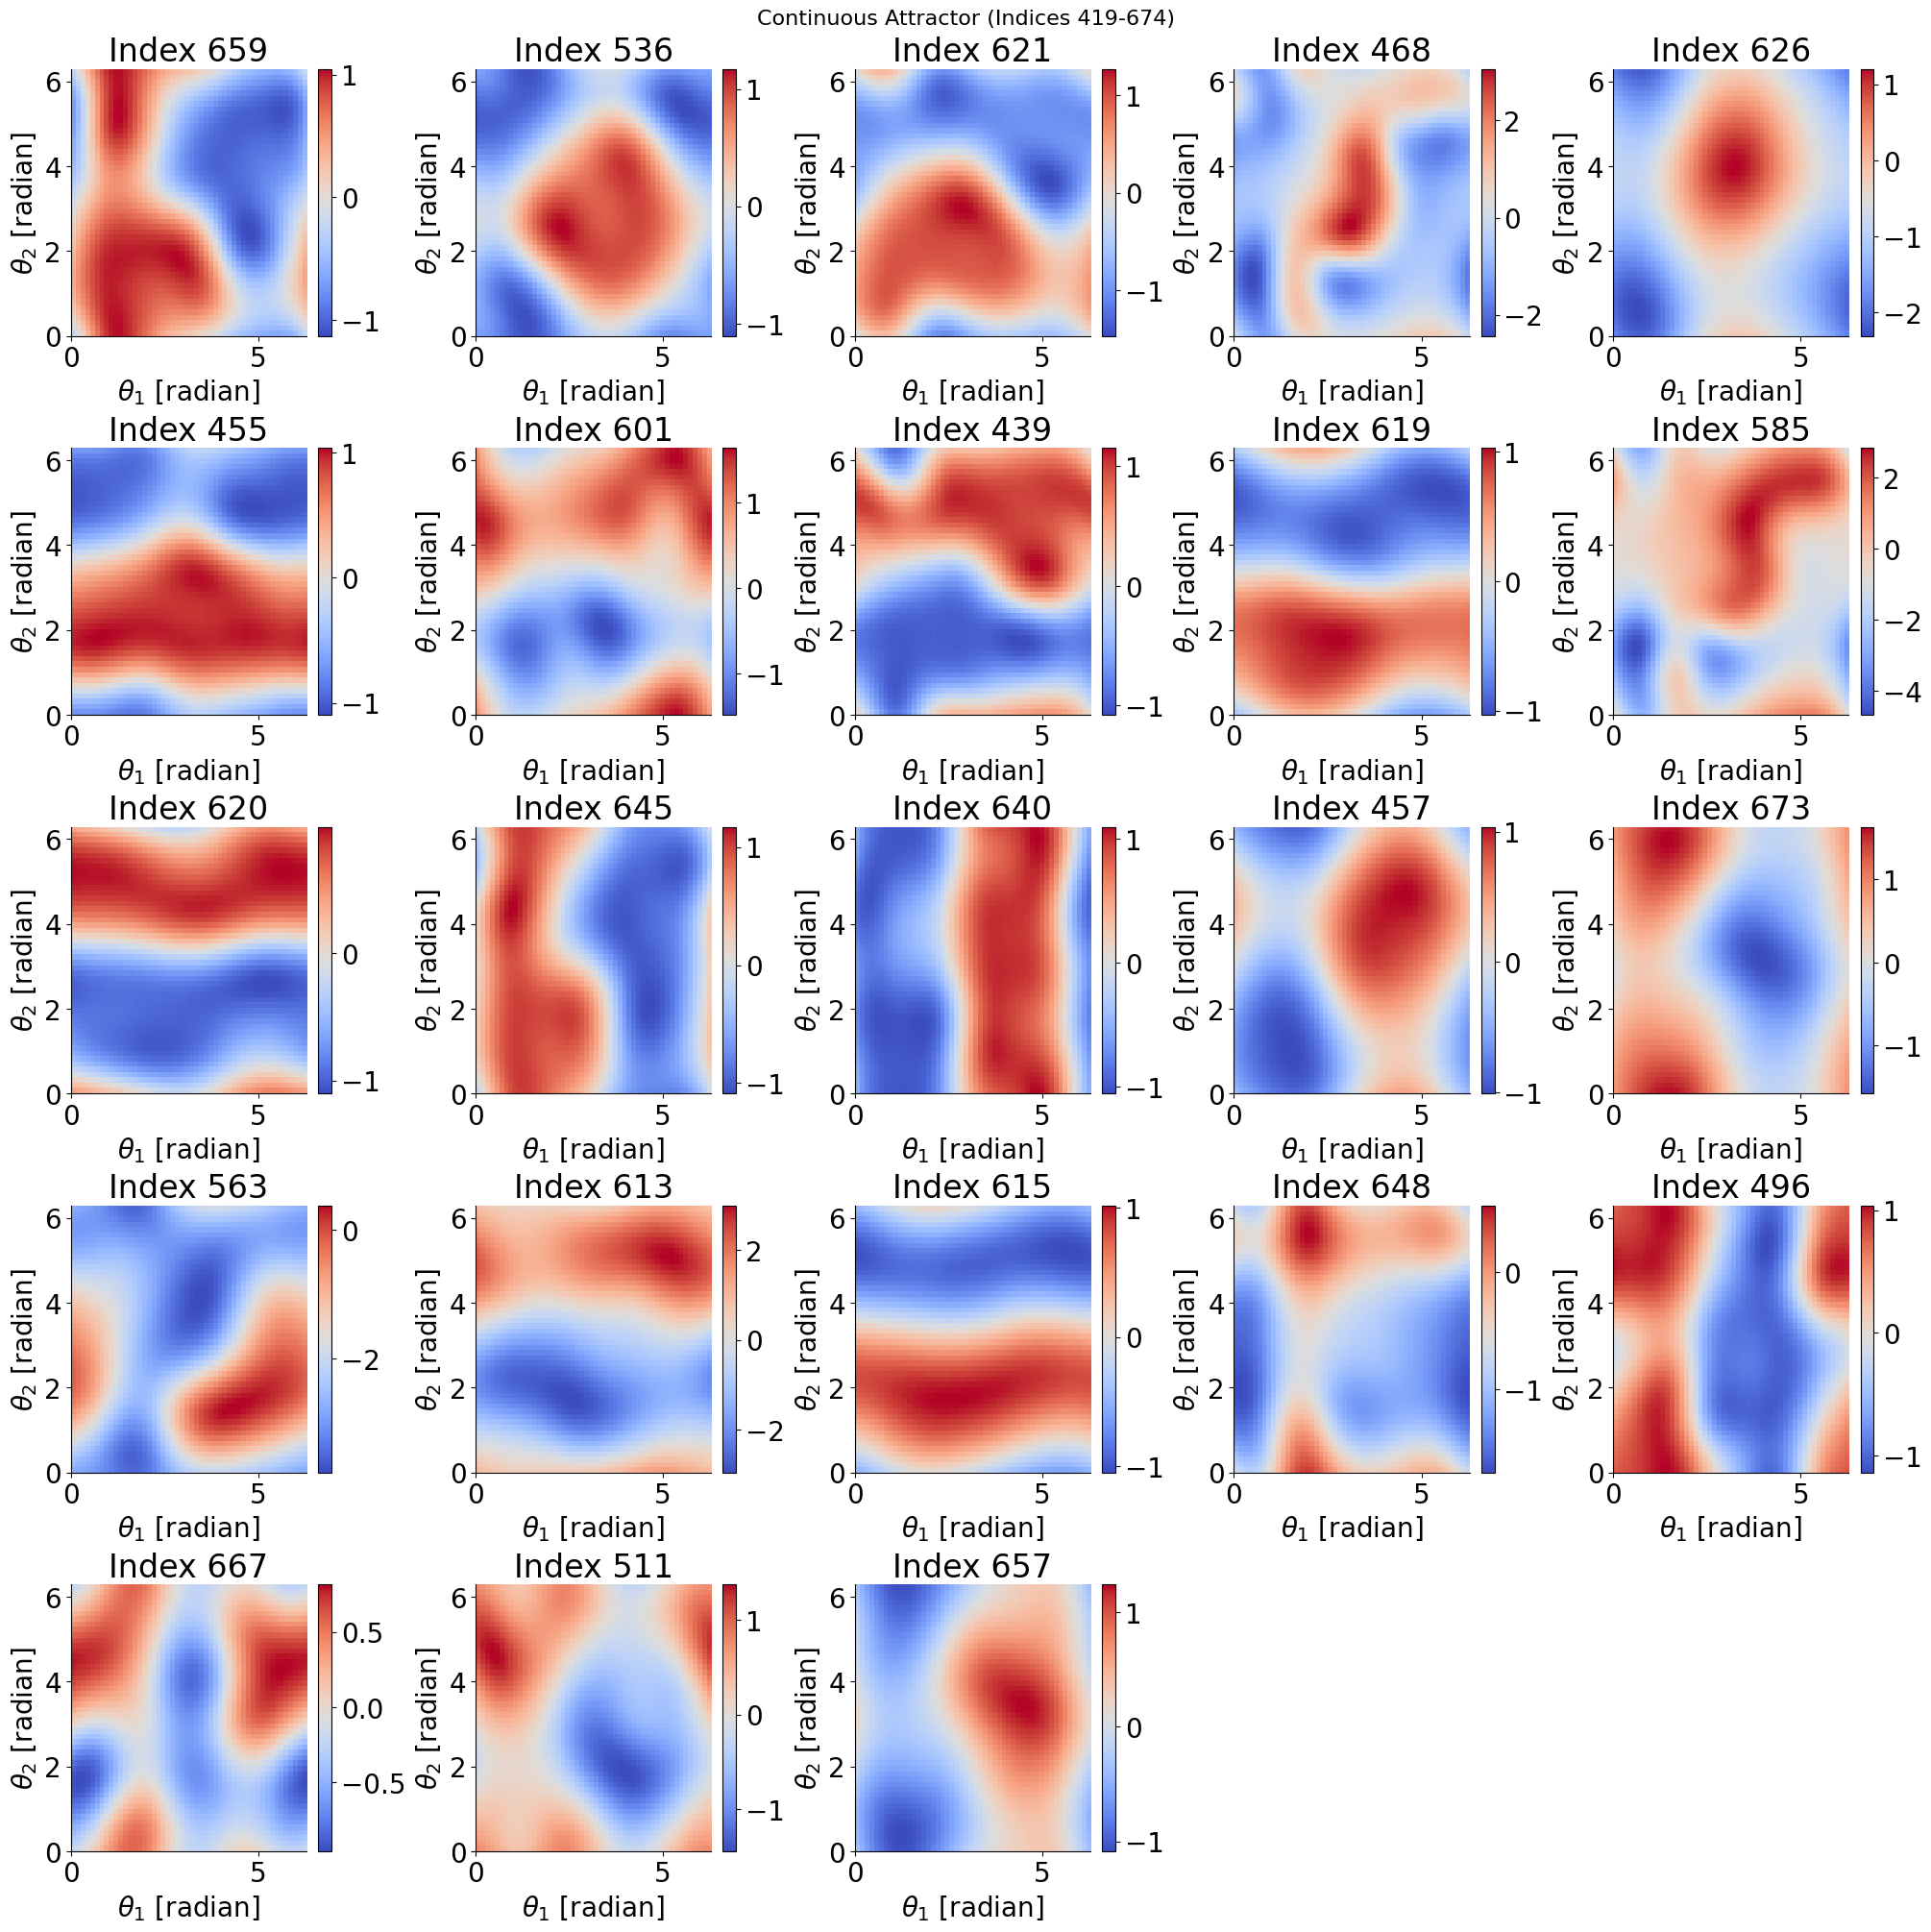

In [106]:
# Create a meshgrid for the 2D tuning curves
theta1 = np.linspace(0, 2 * np.pi, 50)
theta2 = np.linspace(0, 2 * np.pi, 50)
theta1_mesh, theta2_mesh = np.meshgrid(theta1, theta2)

# Combine the meshgrid into a query tensor
query = torch.tensor(
    np.stack([theta1_mesh.ravel(), theta2_mesh.ravel()], axis=-1),
    dtype=torch.get_default_dtype(),
    device=device,
)[None, ...].unsqueeze(-1)

# Predict mean and variance
fmean, fvar = model.obs.predict(query.to("cpu"), full_cov=False)
fstd = fvar.sqrt()

# Reshape the results to match the meshgrid
fmean = fmean[0].cpu().detach().numpy().reshape(50, 50, -1)
fstd = fstd[0].cpu().detach().numpy().reshape(50, 50, -1)

# Define the partitions
partitions = {
    "Internal Model": (0, 128),
    "Predictive Model": (129, 258),
    "Controller": (259, 418),
    "Continuous Attractor": (419, 674),
}

# Iterate over each partition and plot separately
for partition_name, (start, end) in partitions.items():
    # Find the indices in the original dataset
    indices = [i for i in range(fmean.shape[-1]) if subsampling_index_2[i] >= start and subsampling_index_2[i] <= end]
    
    # Subset the fmean for the current partition
    fmean_subset = fmean[:, :, indices]
    num_neurons = fmean_subset.shape[-1]
    
    # Determine grid size for plotting
    cols = 5
    rows = (num_neurons + cols - 1) // cols  # Calculate rows dynamically based on number of neurons
    
    # Create a grid of heatmaps
    fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4), constrained_layout=True)
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        ax = axes[i]
        heatmap = ax.imshow(
            fmean_subset[:, :, i],
            extent=(0, 2 * np.pi, 0, 2 * np.pi),
            origin="lower",
            cmap="coolwarm",
            aspect="auto",
        )
        ax.set_title(f"Index {subsampling_index_2[idx]}")
        ax.set_xlabel(r"$\theta_1$ [radian]")
        ax.set_ylabel(r"$\theta_2$ [radian]")
        fig.colorbar(heatmap, ax=ax, orientation="vertical")
    
    # Hide unused subplots
    for j in range(num_neurons, len(axes)):
        axes[j].axis("off")
    
    # Add a title for the grid
    plt.suptitle(f"{partition_name} (Indices {start}-{end})", fontsize=16)
    plt.show()


In [42]:
# save the model 
torch.save(model.state_dict(), "/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_unsupervised_t2.pt")
torch.save({"index 1": subsampling_index_1, "index 2": subsampling_index_2}, "/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_unsupervised_t2_indices.pt")

The unsupervised model affords some delineation between cell classes based on firing properties; however, this is not robust at all and there is no interpretability. Specifically, though we know that the representation and prediction populations will only be tuned to a particular, shared, latent subspace, mGPLVM seems to fail to recognize this. 

In [15]:
query.shape

torch.Size([1, 2500, 2])

In [94]:
# Try again with more subsamples to see if things get any better
m = 100
n = 200
subsampling_index_1 = torch.randperm(neural_activations.shape[0])[:m]
# subsampling_index_2 = torch.randperm(neural_activations.shape[-1])[:n]
neural_activations_subsampled = neural_activations.reshape(-1, neural_activations.shape[-1])[subsampling_index_1]
print(f"subsampled to shape {neural_activations_subsampled.shape}")
m, n = neural_activations_subsampled.shape
neural_activations_subsampled = neural_activations_subsampled.unsqueeze(0).permute(0, 2, 1).cpu().detach()


subsampled to shape torch.Size([100, 545])


In [47]:
d = 2 # 2 for now; maybe try 3 later
def build_model(): 
    manif = mgp.manifolds.Torus(m, d)
    lat_dist = mgp.rdist.ReLie(manif, m, n_samples=1)
    kernel = mgp.kernels.QuadExp(n, manif.distance)
    lik = mgp.likelihoods.Gaussian(n)
    lprior = mgp.lpriors.Uniform(manif)
    z = manif.inducing_points(n, 50)
    model = mgp.models.SvgpLvm(
        n, m, 1, z, kernel, lik, lat_dist, lprior, whiten = True,
    ).to(device)
    return model

model = build_model()

train_opts = {
    "lrate": 5e-2,
    "max_steps": 1000,
    "n_mc": 64,
    "print_every": 10,
    "burnin": 30 / 5e-2,
    "optimizer": torch.optim.Adam,
}

# train model
progress = mgp.optimisers.svgp.fit(neural_activations_subsampled.cuda(), model, **train_opts)

iter   0 | elbo -6.415 | kl  0.001 | loss  6.415 | |mu| 0.107 | sig 1.500 | scale 1.000 | ell 2.000 | lik_sig 1.000 |
iter  10 | elbo -2.479 | kl  0.001 | loss  2.479 | |mu| 0.100 | sig 1.498 | scale 1.000 | ell 1.999 | lik_sig 1.001 |
iter  20 | elbo -1.953 | kl  0.001 | loss  1.953 | |mu| 0.132 | sig 1.492 | scale 0.999 | ell 2.001 | lik_sig 1.003 |
iter  30 | elbo -1.775 | kl  0.001 | loss  1.775 | |mu| 0.170 | sig 1.484 | scale 0.998 | ell 2.005 | lik_sig 1.005 |
iter  40 | elbo -1.700 | kl  0.001 | loss  1.700 | |mu| 0.360 | sig 1.474 | scale 0.998 | ell 2.010 | lik_sig 1.007 |
iter  50 | elbo -1.643 | kl  0.001 | loss  1.643 | |mu| 0.746 | sig 1.461 | scale 0.997 | ell 2.013 | lik_sig 1.008 |
iter  60 | elbo -1.600 | kl  0.001 | loss  1.601 | |mu| 1.159 | sig 1.440 | scale 0.996 | ell 2.016 | lik_sig 1.009 |
iter  70 | elbo -1.575 | kl  0.001 | loss  1.576 | |mu| 1.340 | sig 1.409 | scale 0.996 | ell 2.019 | lik_sig 1.009 |
iter  80 | elbo -1.553 | kl  0.002 | loss  1.553 | |mu| 

KeyboardInterrupt: 

Load the supervised training data and see if we can get a better fit. 
There are in principle 4 channels: the current position, the distance to go, the final position, and the initial position

In [2]:
model_name = "LAL_weight_decay"
neural_activations = torch.load(f"/home/timmy/storage/mental_rotations/saved_datasets/network_activity_{model_name}.pt")
cx = torch.load(f"/home/timmy/storage/mental_rotations/saved_datasets/positions_{model_name}.pt")
positions = torch.tensor(cx[:, :2].reshape(-1, neural_activations.shape[-2], 2))
scaling = 1
positions[..., 1] = ((positions[..., 1] + np.pi) % (2 * np.pi) * scaling) + (1- scaling) * np.pi - np.pi
neural_activations = neural_activations.reshape(-1, neural_activations.shape[-1])
positions = positions.reshape(-1, positions.shape[-1])


In [3]:
positions.shape

torch.Size([163840, 2])

In [4]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

In [9]:
# Subsample the conditions
m = 8000
n = [64, 64, 32, 20]
load = False

if model_name is not None: 
    partitions = {
        "Internal Model": (0, 128),
        "Controller_hidden": (128, 128 + 128),
        "Controller_output": (256, 288), 
        "Continuous Attractor": (290, 545),
    }
else:
    partitions = {
        "Internal Model": (0, 128),
        "Predictive Model": (128, 258),
        "Controller": (258, 418),
        "Continuous Attractor": (418, 674),
    }
if load: 
    try: 
        indices = torch.load("/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2_indices.pt")
        subsampling_index_1 = indices["index 1"]
        subsampling_index_2 = indices["index 2"]
    except:
        print("No indices found; subsampling randomly")
        subsampling_index_1 = torch.randperm(neural_activations.shape[0])[:m]
        subsampling_index_2 = torch.randperm(neural_activations.shape[-1])[:n]
else: 
    subsampling_index_1 = torch.randperm(neural_activations.shape[0])[:m]
    if model_name is None:
        subsampling_index_2 = torch.randperm(neural_activations.shape[-1])[:n]
    else:
        subsampling_index_2 = []
        for i, (partition_name, (start, end)) in enumerate(partitions.items()):
            partition_indices = torch.arange(start, end)
            sampled_indices = partition_indices[torch.randperm(len(partition_indices))[:n[i]]]
            subsampling_index_2.append(sampled_indices)
        subsampling_index_2 = torch.cat(subsampling_index_2)

neural_activations_subsampled = neural_activations.reshape(-1, neural_activations.shape[-1])[subsampling_index_1][:, subsampling_index_2]
positions_subsampled = positions.reshape(-1, positions.shape[-1])[subsampling_index_1]
print(f"Neural activations subsampled to shape {neural_activations_subsampled.shape}")
print(f"Positions subsampled to shape {positions_subsampled.shape}")
m, n = neural_activations_subsampled.shape
neural_activations_subsampled = neural_activations_subsampled.unsqueeze(0).permute(0, 2, 1).cpu().detach()


Neural activations subsampled to shape torch.Size([8000, 180])
Positions subsampled to shape torch.Size([8000, 2])


In [97]:
n

545

(array([3665., 3660., 3556., 3167., 3347., 3413., 3502., 3608., 3718.,
        3808., 3628., 3165., 3065., 2982., 2843., 2980., 2938., 2936.,
        3024., 3054., 3084., 3063., 3013., 3199., 3078., 2613., 2333.,
        2295., 2309., 2351., 2596., 2571., 2847., 2859., 3186., 3173.,
        3377., 3476., 3622., 3487., 3662., 3747., 3892., 4077., 4492.,
        4246., 4083., 3851., 3620., 3579.]),
 array([3.42060484e-05, 1.25697196e-01, 2.51360208e-01, 3.77023190e-01,
        5.02686203e-01, 6.28349185e-01, 7.54012167e-01, 8.79675210e-01,
        1.00533819e+00, 1.13100123e+00, 1.25666416e+00, 1.38232720e+00,
        1.50799012e+00, 1.63365316e+00, 1.75931621e+00, 1.88497913e+00,
        2.01064205e+00, 2.13630509e+00, 2.26196814e+00, 2.38763118e+00,
        2.51329422e+00, 2.63895702e+00, 2.76462007e+00, 2.89028311e+00,
        3.01594615e+00, 3.14160919e+00, 3.26727223e+00, 3.39293504e+00,
        3.51859808e+00, 3.64426112e+00, 3.76992416e+00, 3.89558721e+00,
        4.02125025e+00, 

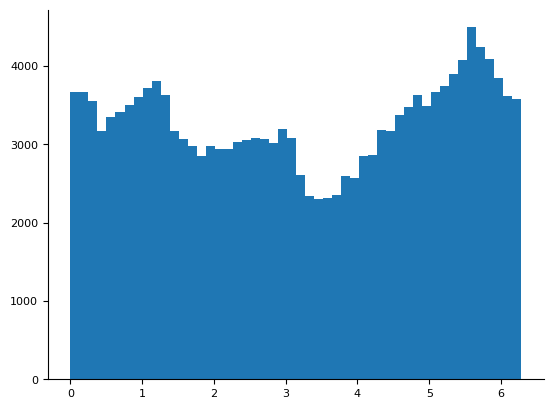

In [ ]:
plt.hist(positions[..., 0].cpu().reshape(-1, 1).numpy(), bins=50)

In [6]:
!nvidia-smi

Tue May 20 13:08:22 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...    Off |   00000000:01:00.0  On |                  N/A |
| N/A   52C    P0             14W /  115W |     854MiB /   8188MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
positions_subsampled.shape

torch.Size([2000, 2])

KeyboardInterrupt: 

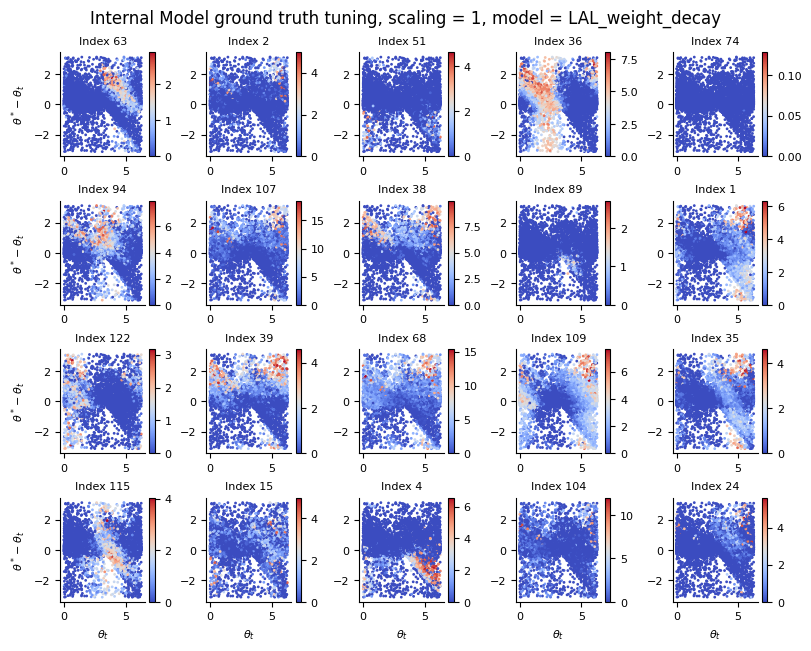

In [10]:
for partition_name, (start, end) in partitions.items():
    indices = [i for i in range(neural_activations_subsampled.shape[-2]) if subsampling_index_2[i] >= start and subsampling_index_2[i] <= end]
    # subset the neural activations for the current partition
    neural_activations_subset = neural_activations_subsampled[:, indices, :]
    num_neurons = neural_activations_subset.shape[-2]
    # determine grid size for plotting
    cols = 5
    # rows = (num_neurons + cols - 1) // cols  # calculate rows dynamically based on number of neurons
    rows = 4
    # create a grid of heatmaps
    fig, axes = plt.subplots(rows, cols, figsize=(8, rows * 8/5), constrained_layout=True)
    axes = axes.flatten()
    for i, idx in enumerate(indices):
        if i >= len(axes):
            break
        ax = axes[i]
        heatmap = ax.scatter(
            positions_subsampled[:, 0],
            positions_subsampled[:, 1],
            c=neural_activations_subset[0, i, :],
            cmap="coolwarm",
            s = 1,
        )
        ax.set_title(f"Index {subsampling_index_2[idx]}")
        if i % cols == 0:
            ax.set_ylabel(r"$\theta^* - \theta_t$")
        if i // cols == rows - 1:
            ax.set_xlabel(r"$\theta_t$")
        fig.colorbar(heatmap, ax=ax, orientation="vertical")

    fig.suptitle(f"{partition_name} ground truth tuning, scaling = {scaling}{", model = " + model_name if model_name is not None else ""}", fontsize=12)
    plt.savefig(f"{FIG_PATH}/GT_modular_{partition_name}_scaling{scaling}{model_name if model_name is not None else ""}.png", dpi=300, bbox_inches='tight')


Now we have an idea of what stuff actually looks like, we try to fit the supervised mGPLVM to data. 

Note that this plot reveals bias in the sampling procedure. This is expected because we are sampling on control trajectories; expectedly as the controller is trained, the residual motion will be biased toward 0 (or 2pi). 

In [11]:
### set some parameters for fitting ###
max_steps = 1001 # number of training iterations
n_mc = 1 # number of monte carlo samples per iteration (since the latents are a delta function, we only need 1)
print_every = 10 # how often we print training progress
d = 2 # specify the dimensionality of the space
n_z = 70 #number of inducing points; performance increases with more inducing points

In [12]:
def build_model_supervised(): 
    manif = mgp.manifolds.Torus(m, d)
    mu = positions_subsampled.unsqueeze(0)
    lat_dist = mgp.rdist.ReLie(manif, m, n_samples=1, sigma = 1e-5, diagonal = True, mu = mu)
    kernel = mgp.kernels.QuadExp(n, manif.distance, Y = neural_activations_subsampled, ell = np.ones(n)*1, scale = 0.7*np.ones(n)) #squared exponential kernel
    # lik = mgp.likelihoods.Gaussian(n, Y = neural_activations_subsampled, d=d)
    lik = mgp.likelihoods.Gaussian(n, )
    lprior = mgp.lpriors.Uniform(manif)
    z = manif.inducing_points(n, n_z)
    model = mgp.models.SvgpLvm(
        n, m, 1, z, kernel, lik, lat_dist, lprior,
    ).to(device)
    return model

def build_model_unsupervised(): 
    manif = mgp.manifolds.Torus(m, d)
    lat_dist = mgp.rdist.ReLie(manif, m, n_samples=1)
    kernel = mgp.kernels.QuadExp(n, manif.distance)
    lik = mgp.likelihoods.Gaussian(n)
    lprior = mgp.lpriors.Uniform(manif)
    z = manif.inducing_points(n, 50)
    model = mgp.models.SvgpLvm(
        n, m, 1, z, kernel, lik, lat_dist, lprior, whiten = True
    )
    return model


model = build_model_supervised()
unsupervised_model = build_model_unsupervised()

/home/timmy/projects/mental-rotations/src/mgplvm/mgplvm/rdist/relie.py:120: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gmu = torch.tensor(mu)


In [16]:
scale = 1/10
manif = mgp.manifolds.Torus(m, d)
manif.distance(
    torch.tensor([[0.0, -np.pi * scale], ], dtype=torch.get_default_dtype()).unsqueeze(2),
    torch.tensor([[0.0, np.pi * scale], ], dtype=torch.get_default_dtype()).unsqueeze(2),
)

tensor([[[0.3820]]])

In [13]:
train_params = mgp.crossval.training_params(max_steps = max_steps, n_mc = n_mc, lrate = 5e-2, callback = None, burnin = 50, mask_Ts = (lambda x: x*0))
print('fitting', n, 'neurons and', m, 'conditions for', max_steps, 'iterations')
mod_train = mgp.crossval.train_model(model, neural_activations_subsampled.to(device), train_params)

fitting 180 neurons and 8000 conditions for 1001 iterations


RuntimeError: CUDA error: CUBLAS_STATUS_ALLOC_FAILED when calling `cublasCreate(handle)`

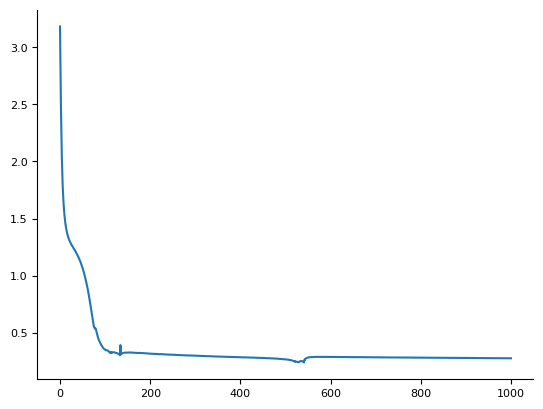

In [21]:
plt.plot(mod_train)

In [22]:
model.load_state_dict(torch.load("/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2.pt"))

<All keys matched successfully>

Model trained; now visualize the tuning. 

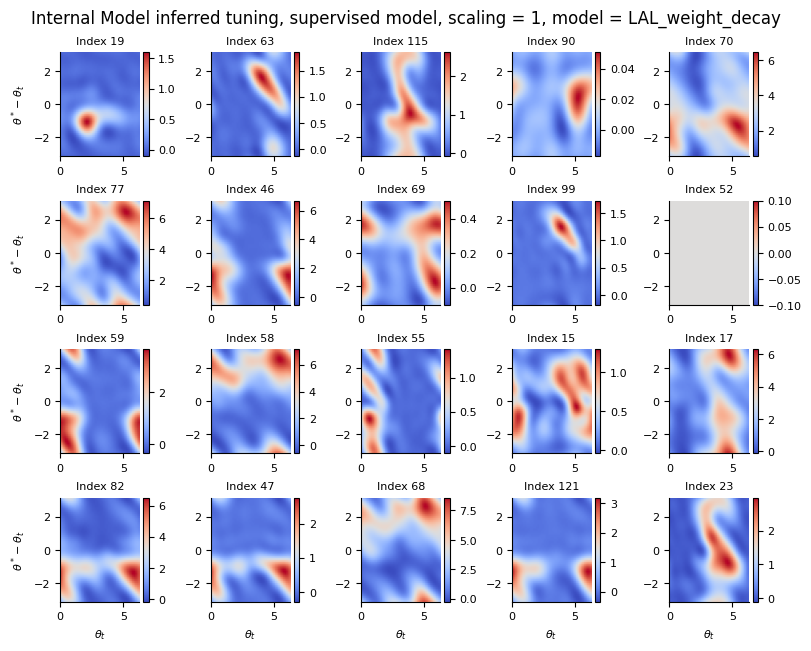

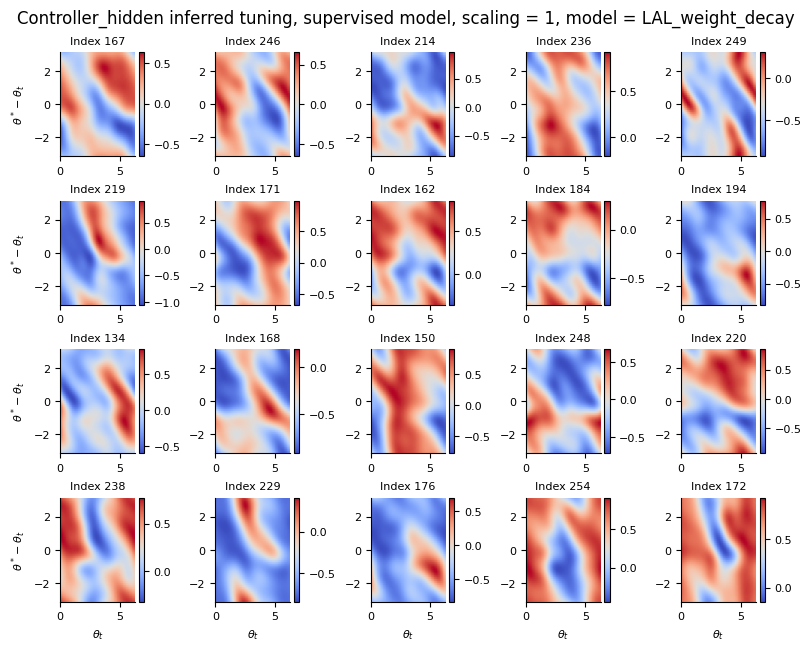

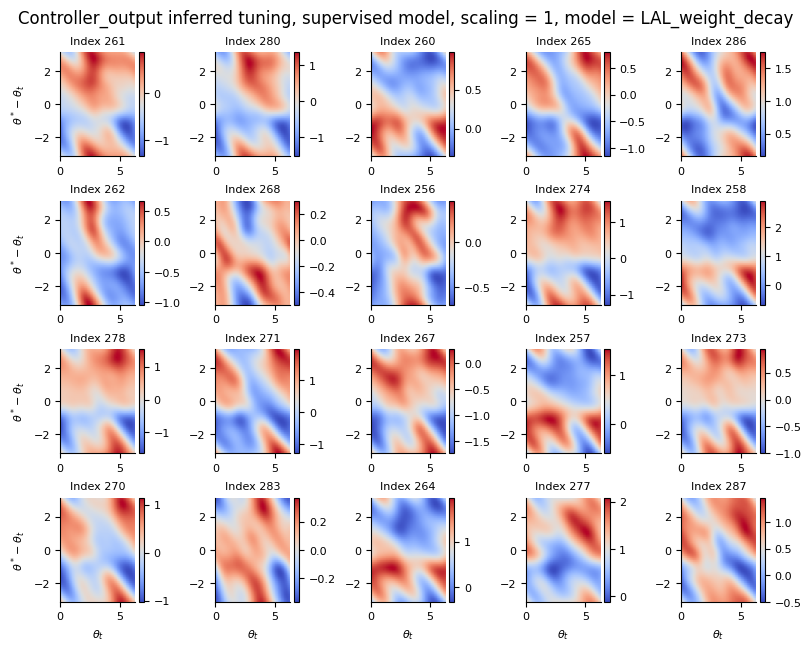

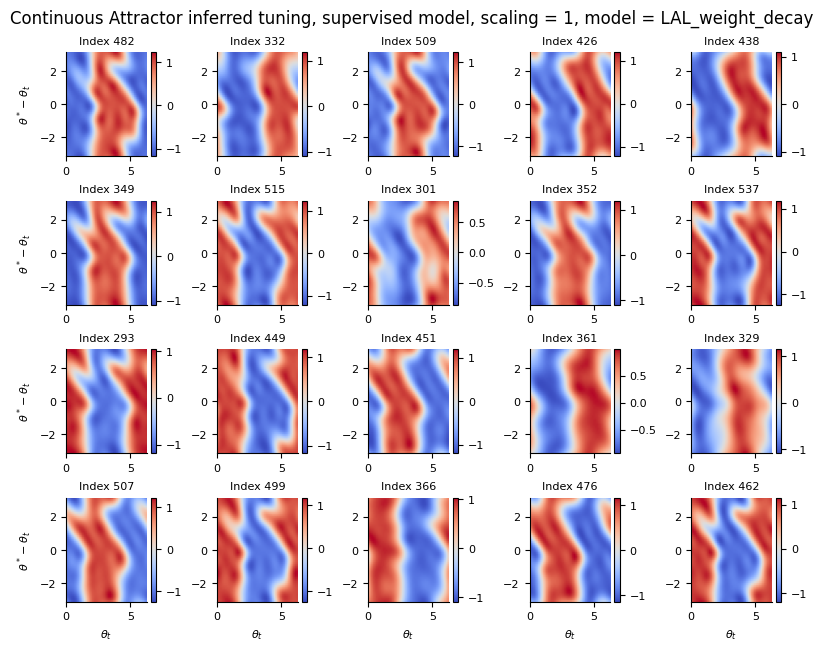

In [22]:
# Create a meshgrid for the 2D tuning curves
theta1 = np.linspace(0, 2 * np.pi, 50)
theta2 = np.linspace(-np.pi * scaling, np.pi * scaling, 50)
theta1_mesh, theta2_mesh = np.meshgrid(theta1, theta2)

# Combine the meshgrid into a query tensor
query = torch.tensor(
    np.stack([theta1_mesh.ravel(), theta2_mesh.ravel()], axis=-1),
    dtype=torch.get_default_dtype(),
    device=device,
)[None, ...].unsqueeze(-1)

# Predict mean and variance
model = model.to("cpu")
fmean, fvar = model.obs.predict(query.to("cpu"), full_cov=False)
fstd = fvar.sqrt()

# Reshape the results to match the meshgrid
fmean = fmean[0].cpu().detach().numpy().reshape(50, 50, -1)
fstd = fstd[0].cpu().detach().numpy().reshape(50, 50, -1)

subsets = {}
# Iterate over each partition and plot separately
for partition_name, (start, end) in partitions.items():
    # Find the indices in the original dataset
    indices = [i for i in range(fmean.shape[-1]) if subsampling-1.  1. -1. -1.  1. -1. -1.  1.]_index_2[i] >= start and subsampling_index_2[i] <= end]
    
    # Subset the fmean for the current partition
    fmean_subset = fmean[:, :, indices]
    num_neurons = fmean_subset.shape[-1]
    subsets[partition_name] = fmean_subset
    
    # Determine grid size for plotting
    cols = 5
    # rows = (num_neurons + cols - 1) // cols  # Calculate rows dynamically based on number of neurons
    rows = 4
    
    # Create a grid of heatmaps
    fig, axes = plt.subplots(rows, cols, figsize=(8, rows * 8/5), constrained_layout=True)
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        if i >= len(axes):
            break
        ax = axes[i]
        heatmap = ax.imshow(
            fmean_subset[:, :, i],
            extent=(0, 2 * np.pi, -np.pi, np.pi),
            origin="lower",
            cmap="coolwarm",
            aspect="auto",
        )
        ax.set_title(f"Index {subsampling_index_2[idx]}")
        if i % cols == 0:
            ax.set_ylabel(r"$\theta^* - \theta_t$")
        if i // cols == rows - 1:
            ax.set_xlabel(r"$\theta_t$")
        # fig.colorbar(heatmap, ax=ax, orientation="vertical")
        fig.colorbar(heatmap, ax=ax, orientation="vertical")
    
   
    # Add a title for the grid
    plt.suptitle(f"{partition_name} inferred tuning, supervised model, scaling = {scaling}{", model = " + model_name if model_name is not None else ""}", fontsize=12)
    plt.savefig(f"{FIG_PATH}/supervised_model_modular_{partition_name}_scaling{scaling}_{model_name if model_name is not None else ""}.png", dpi=300, bbox_inches='tight')
    plt.show()


In [23]:
torch.save(model.state_dict(), f"/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2_{model_name}.pt")
torch.save({"index 1": subsampling_index_1, "index 2": subsampling_index_2}, f"/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2_indices_{model_name}.pt")

# Single dimension tuning analysis

To further replicate figures in Mussells Pires et al. 2024, we look at single dimensional tuning curves.


## Observation 1: joint tuning

- this corresponds to figure 3 in the paper
- 3d: observing that lots of cells are tuned to a current angle. 

In [25]:
controller_population_activity = neural_activations[:, partitions["Controller_output"][0]:partitions["Controller_output"][1]]
subsampled_controller_population_activity = neural_activations[subsampling_index_1][:, partitions["Controller_output"][0]:partitions["Controller_output"][1]].cpu().detach().numpy()

In [26]:
print(subsampled_controller_population_activity.shape)
print(positions_subsampled.shape)
current_angles = positions_subsampled[:, 0].cpu().numpy()
residual_angles = positions_subsampled[:, 1].cpu().numpy()
target_angles = (current_angles + residual_angles) % (2 * np.pi)

(8000, 32)
torch.Size([8000, 2])


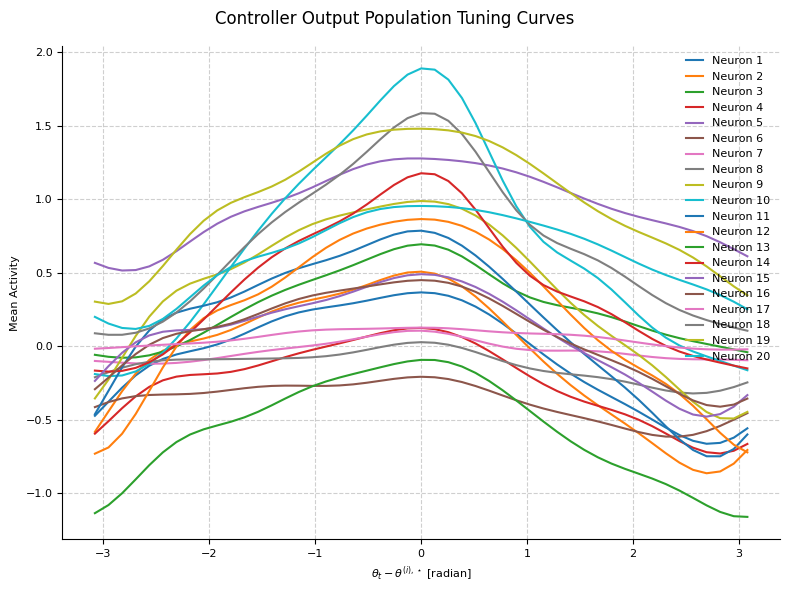

In [111]:
controller_means = subsets["Controller_output"]
theta = (theta1 + np.pi) % (2 * np.pi) - np.pi
theta = theta[:-1]

plt.figure(figsize=(8, 6))
for i in range(controller_means.shape[-1]):
    trace = controller_means[..., i].mean(axis=1)[:-1]
    shift = np.argmax(trace)  # Find the peak to align
    shifted_trace = np.roll(trace, -25-shift)
    shifted_theta = np.roll(theta, -25)  # Roll theta to match the trace
    plt.plot(shifted_theta, shifted_trace, label=f"Neuron {i+1}")

plt.xlabel(r"$\theta_t - \theta^{(i), \star}$ [radian]")
plt.ylabel("Mean Activity")
plt.suptitle("Controller Output Population Tuning Curves")
plt.legend(loc="upper right", fontsize=8, frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(f"{FIG_PATH}/controller_population_tuning_curves.png", dpi=300, bbox_inches="tight")
plt.show()

In [38]:
state_dict = torch.load(MODEL_SAVE_PATH + "/LAL/modularized_cp_5")
model_state_dict = state_dict["model_state_dict"]

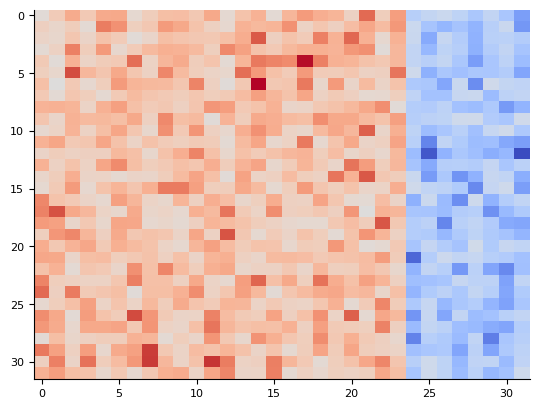

In [40]:
import torch.nn.functional as F

W_pos = F.softplus(model_state_dict["plant.W_param"]) * model_state_dict["plant.dale_signs"]
plt.imshow(W_pos.cpu().numpy(), cmap="coolwarm", aspect="auto")

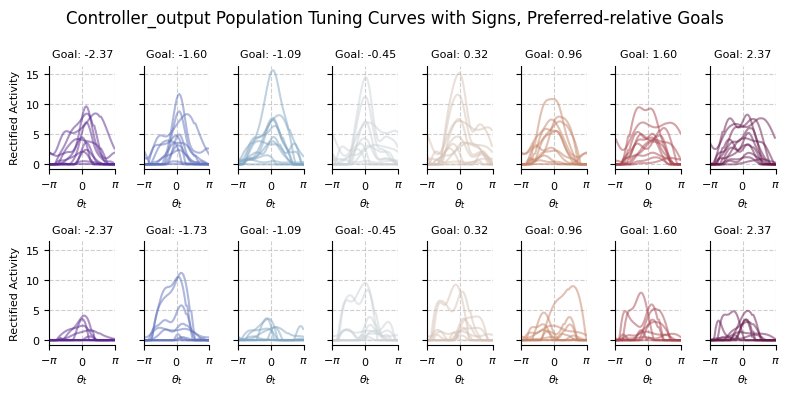

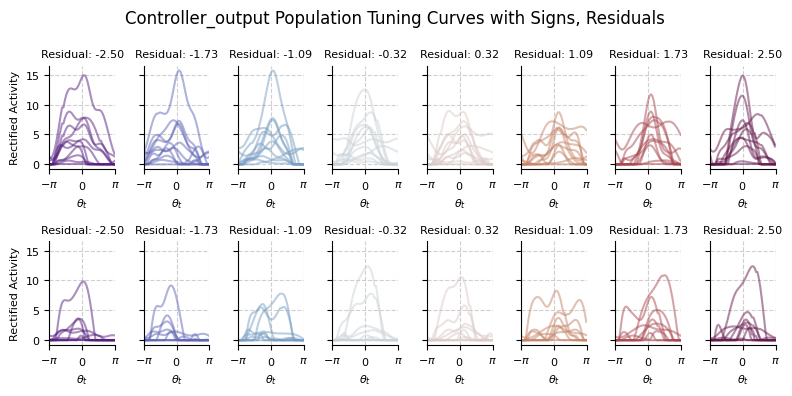

In [163]:
squared = False
scaled = True
controller_signs = torch.sign(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0))
controller_signs = controller_signs.cpu().numpy()
controller_mags = torch.abs(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0)).cpu().numpy()
utils.plot_joint_tuning("Controller_output", subsets, theta1, theta2, controller_signs, controller_mags, squared = squared, scaled = scaled, save = True, show = True)

In [139]:
np.linspace(0, 50, 10)[1:-1]

array([ 5.55555556, 11.11111111, 16.66666667, 22.22222222, 27.77777778,
       33.33333333, 38.88888889, 44.44444444])

In [138]:
relative_goal

array([-3.14159265, -3.14159265, -3.01336438, -2.88513611, -2.75690784,
       -2.62867957, -2.5004513 , -2.37222302, -2.24399475, -2.11576648,
       -1.98753821, -1.85930994, -1.73108167, -1.60285339, -1.47462512,
       -1.34639685, -1.21816858, -1.08994031, -0.96171204, -0.83348377,
       -0.70525549, -0.57702722, -0.44879895, -0.32057068, -0.19234241,
       -0.06411414,  0.06411414,  0.19234241,  0.32057068,  0.44879895,
        0.57702722,  0.70525549,  0.83348377,  0.96171204,  1.08994031,
        1.21816858,  1.34639685,  1.47462512,  1.60285339,  1.73108167,
        1.85930994,  1.98753821,  2.11576648,  2.24399475,  2.37222302,
        2.5004513 ,  2.62867957,  2.75690784,  2.88513611,  3.01336438])

## what we found was that the output control cells are organized by residual rotations. 

What about the hidden cells?

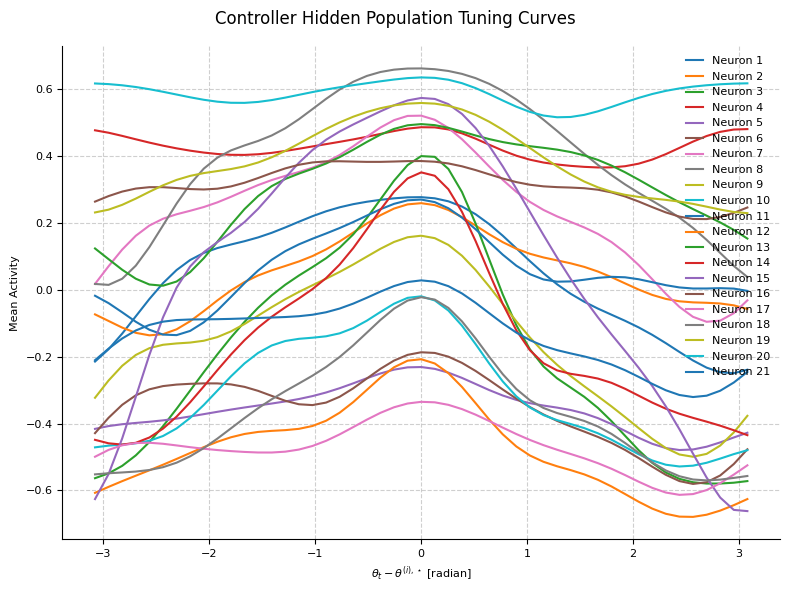

In [112]:
controller_means = subsets["Controller_hidden"]
theta = (theta1 + np.pi) % (2 * np.pi) - np.pi
theta = theta[:-1]

plt.figure(figsize=(8, 6))
for i in range(controller_means.shape[-1]):
    trace = controller_means[..., i].mean(axis=1)[:-1]
    shift = np.argmax(trace)  # Find the peak to align
    shifted_trace = np.roll(trace, -25-shift)
    shifted_theta = np.roll(theta, -25)  # Roll theta to match the trace
    plt.plot(shifted_theta, shifted_trace, label=f"Neuron {i+1}")

plt.xlabel(r"$\theta_t - \theta^{(i), \star}$ [radian]")
plt.ylabel("Mean Activity")
plt.suptitle("Controller Hidden Population Tuning Curves")
plt.legend(loc="upper right", fontsize=8, frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(f"{FIG_PATH}/controller_population_tuning_curves_hidden.png", dpi=300, bbox_inches="tight")
plt.show()

[-1. -1.  1. -1.  1.  1. -1. -1.  1.  1.  1. -1. -1.  1.  1. -1.  1.  1.
 -1.  1.  1.  1. -1.  1.  1. -1.  1.  1. -1.  1.  1. -1.]


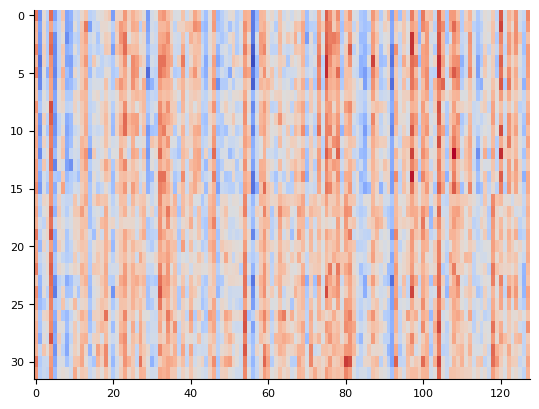

In [116]:
W_control = W_pos @ model_state_dict["out.weight"] 
plt.imshow(W_control.cpu().numpy(), cmap="coolwarm", aspect="auto")
controller_signs = torch.sign(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0))
controller_signs = controller_signs.cpu().numpy()
print(controller_signs)

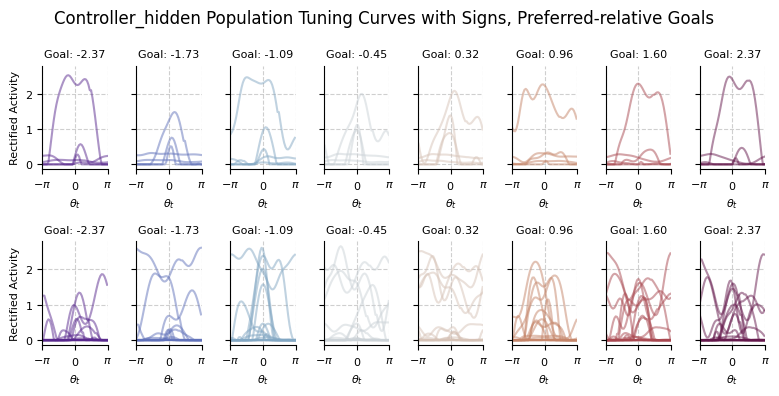

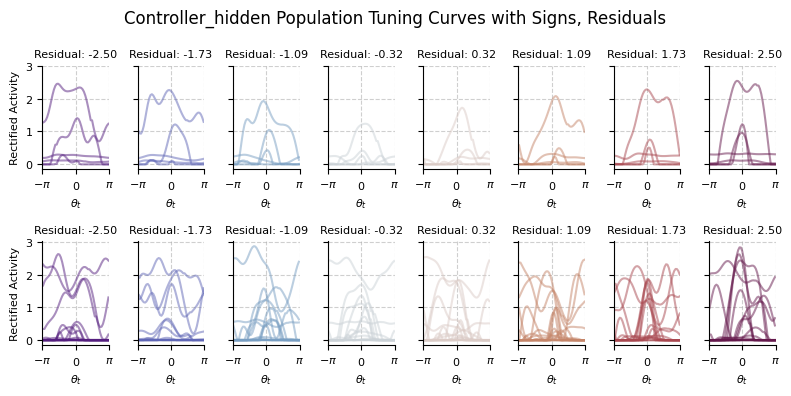

In [162]:
controller_signs = torch.sign(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0))
controller_mags = torch.abs(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0)).cpu().numpy()
controller_signs = controller_signs.cpu().numpy()

utils.plot_joint_tuning("Controller_hidden", subsets, theta1, theta2, controller_signs, controller_mags, squared = False, scaled = True, save = True, show = True)

In [157]:
angle_pref = theta[shift]

relative_goal = (theta2 + theta1 - angle_pref + np.pi) % (2 * np.pi) - np.pi
shifted_trace = np.roll(trace, -25-shift, axis=0).clip(min = 0)
shifted_theta = np.roll(theta, -25, axis=0)
sorted_indices = np.argsort(relative_goal)
relative_goal = relative_goal[sorted_indices]


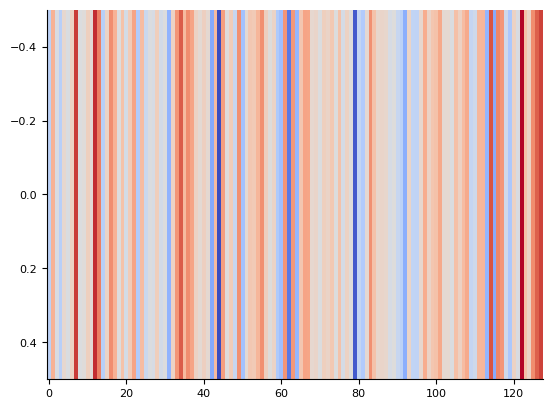

In [147]:
plt.imshow(model_state_dict["im1.W_output.weight"].cpu().detach().numpy(), cmap = "coolwarm", aspect = "auto")

In [164]:
subsets.keys()

dict_keys(['Internal Model', 'Controller_hidden', 'Controller_output', 'Continuous Attractor'])

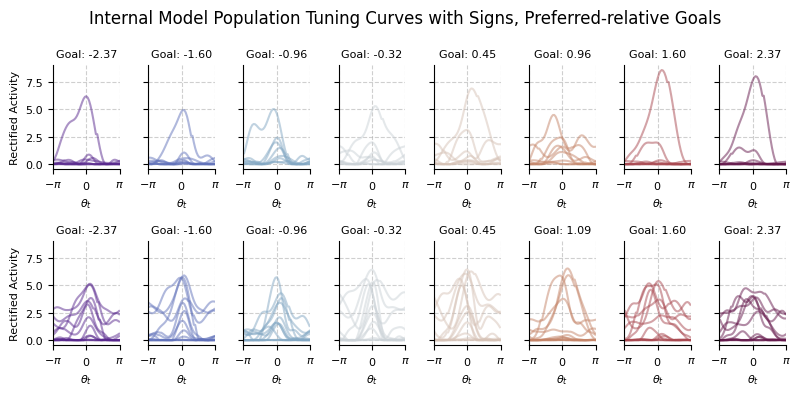

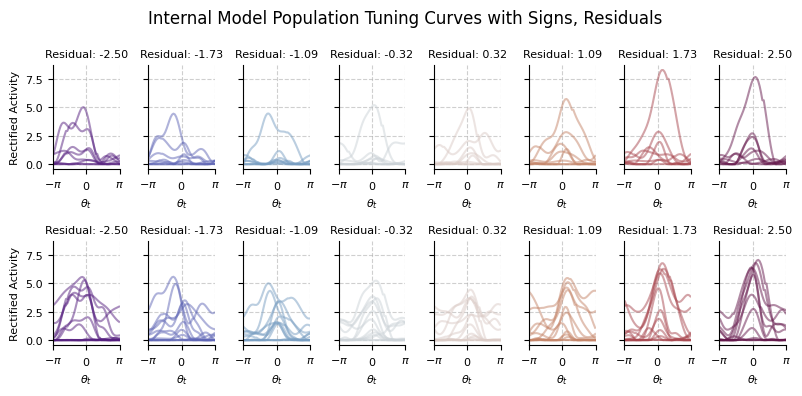

In [166]:
squared = False
scaled = False
controller_signs = torch.sign(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()
controller_mags = torch.abs(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()
utils.plot_joint_tuning("Internal Model", subsets, theta1, theta2, controller_signs, controller_mags, squared = squared, scaled = scaled, save = True, show = True)

In [171]:
subsampled_controller_hidden = neural_activations[subsampling_index_1][:, partitions["Controller_hidden"][0]:partitions["Controller_hidden"][1]]


In [173]:
positions_subsampled.shape

torch.Size([8000, 2])

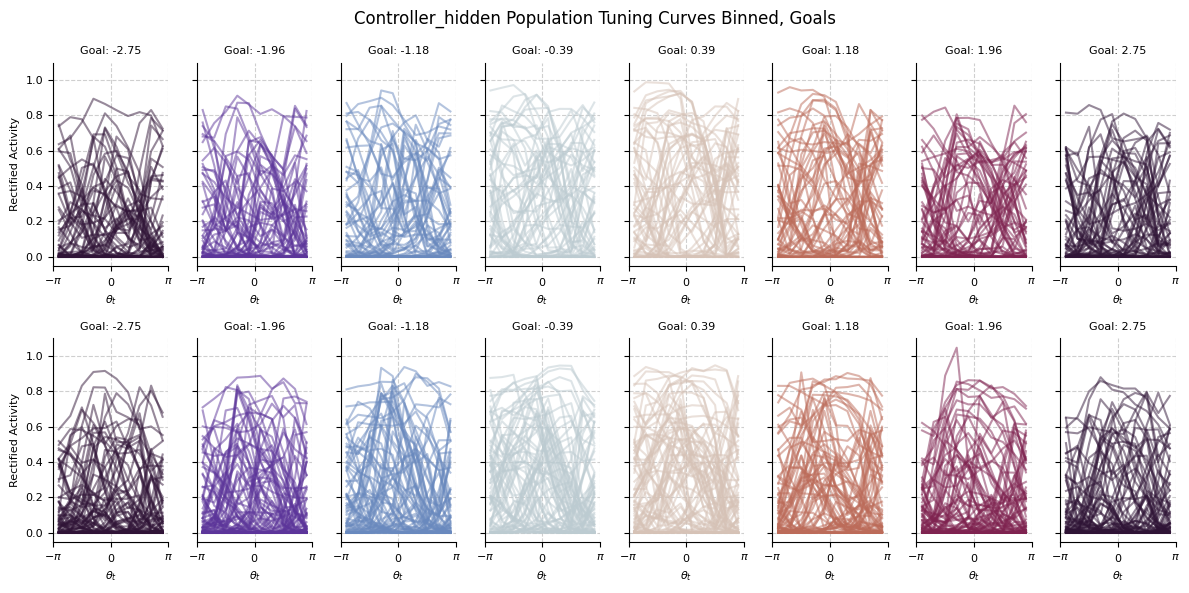

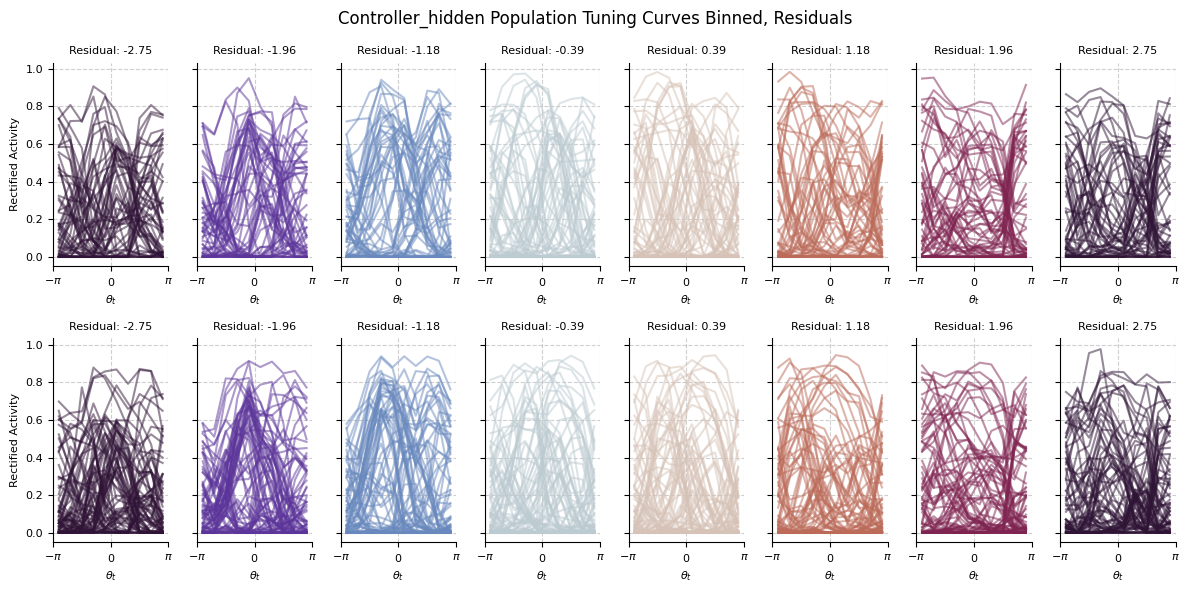

In [185]:
squared = False
scaled = False
controller_signs = torch.sign(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0))
controller_mags = torch.abs(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0)).cpu().numpy()
controller_signs = controller_signs.cpu().numpy()

utils.plot_joint_tuning_binned(
    activations=subsampled_controller_hidden,
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    thetas = positions_subsampled, 
    squared=squared, scaled=scaled, 
    save = False, show = True, n_bins = 8,n_theta_bins = 10, population = "Controller_hidden",
)

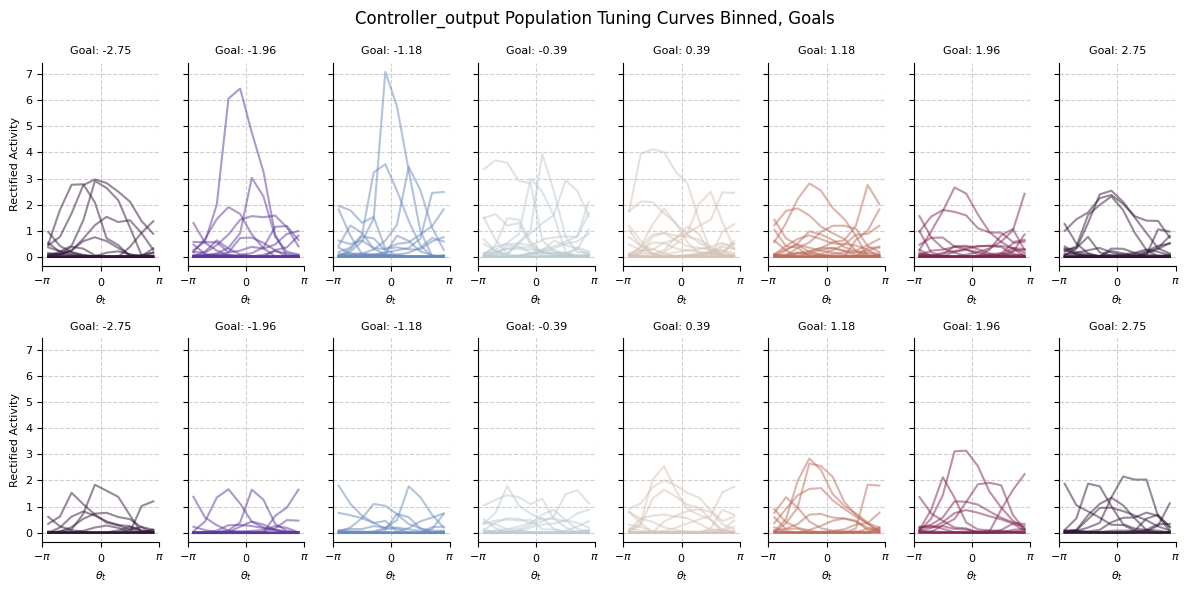

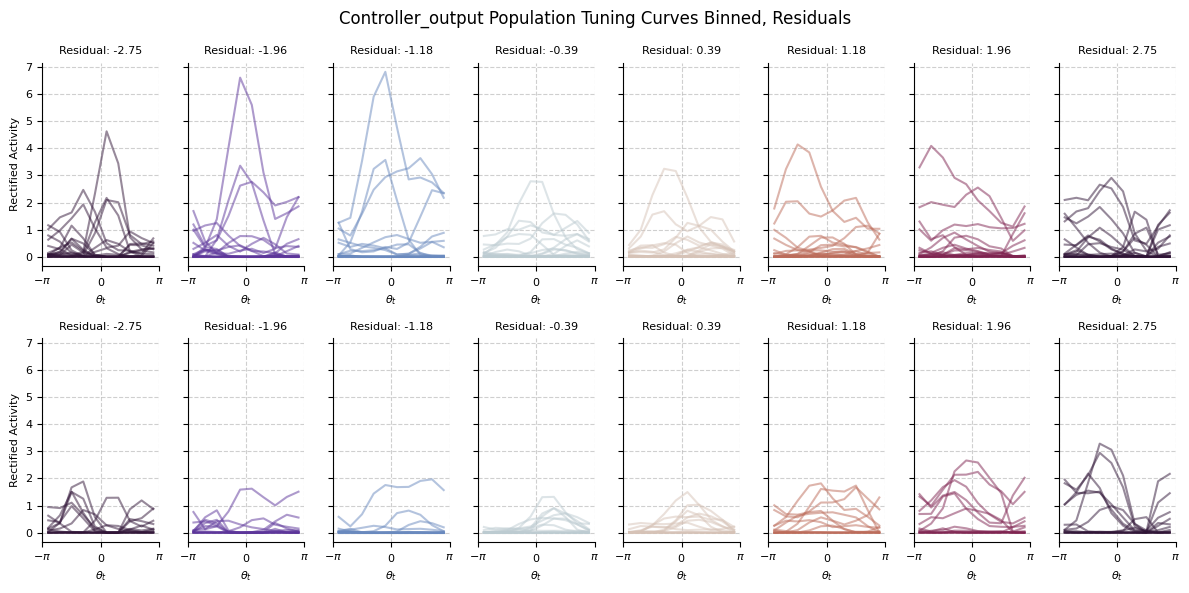

In [190]:
population = "Controller_output"
squared = True
scaled = False
controller_signs = torch.sign(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0))
controller_mags = torch.abs(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0)).cpu().numpy()
controller_signs = controller_signs.cpu().numpy()
subsampled_controller_hidden = neural_activations[subsampling_index_1][:, partitions[population][0]:partitions[population][1]]
utils.plot_joint_tuning_binned(
    activations=subsampled_controller_hidden,
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    thetas = positions_subsampled, 
    squared=squared, scaled=scaled, 
    save = False, show = True, n_bins = 8,n_theta_bins = 10, population =population,
)

In [ ]:
controller_signs = torch.sign(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0))
controller_mags = torch.abs(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0)).cpu().numpy()
controller_signs = controller_signs.cpu().numpy()
utils.plot_joint_tuning("Controller_hidden", subsets, theta1, theta2, controller_signs, controller_mags, squared = False, scaled = True, save = True, show = True)

This is much better! and expected too. But what happened? The unsupervised model should have been able to learn this - let's try to reproduce the training conditions and see how exactly the unsupervised model fails.

In [17]:
train_params = mgp.crossval.training_params(max_steps = max_steps, n_mc = n_mc, lrate = 5e-2, callback = None, burnin = 50, mask_Ts = (lambda x: x*0))
print('fitting', n, 'neurons and', m, 'conditions for', max_steps, 'iterations')
mod_train = mgp.crossval.train_model(unsupervised_model.to(device), neural_activations_subsampled.to(device), train_params)

fitting 100 neurons and 1000 conditions for 1001 iterations
iter   0 | elbo -5.676 | kl  0.002 | loss  5.676 | |mu| 0.101 | sig 1.500 | scale 1.000 | ell 2.000 | lik_sig 1.000 |
iter  50 | elbo -1.709 | kl  0.002 | loss  1.710 | |mu| 0.101 | sig 1.500 | scale 0.968 | ell 2.150 | lik_sig 1.070 |
iter 100 | elbo -1.455 | kl  0.003 | loss  1.457 | |mu| 0.101 | sig 1.500 | scale 0.944 | ell 2.256 | lik_sig 0.963 |
iter 150 | elbo -1.384 | kl  0.002 | loss  1.386 | |mu| 0.101 | sig 1.500 | scale 0.912 | ell 2.366 | lik_sig 0.968 |
iter 200 | elbo -1.358 | kl  0.002 | loss  1.359 | |mu| 0.101 | sig 1.500 | scale 0.884 | ell 2.468 | lik_sig 0.987 |
iter 250 | elbo -1.341 | kl  0.002 | loss  1.344 | |mu| 0.101 | sig 1.500 | scale 0.857 | ell 2.578 | lik_sig 1.000 |
iter 300 | elbo -1.333 | kl  0.002 | loss  1.335 | |mu| 0.101 | sig 1.500 | scale 0.831 | ell 2.695 | lik_sig 1.009 |
iter 350 | elbo -1.326 | kl  0.003 | loss  1.329 | |mu| 0.101 | sig 1.500 | scale 0.806 | ell 2.818 | lik_sig 1.01

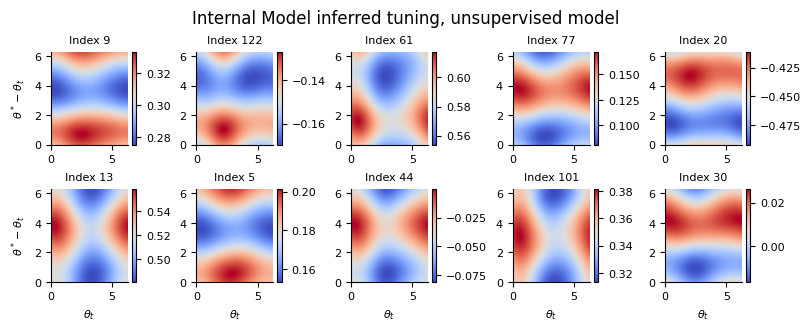

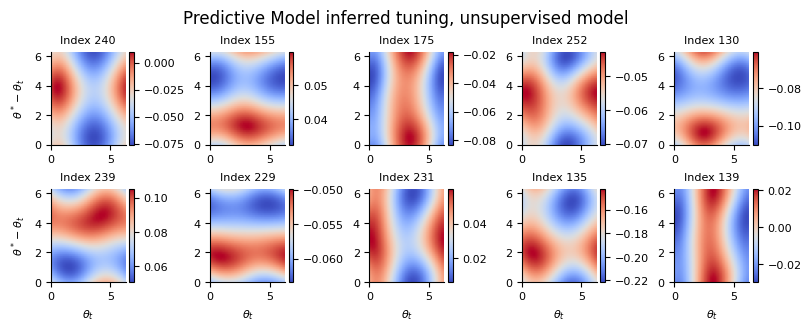

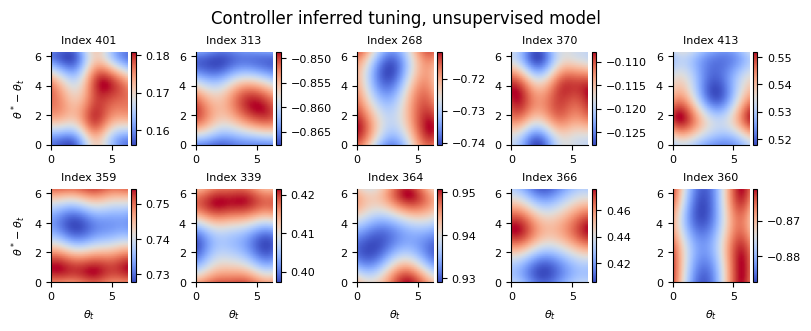

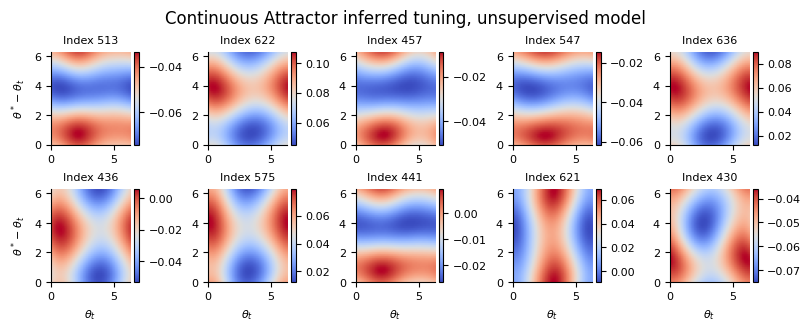

In [18]:
# Create a meshgrid for the 2D tuning curves
theta1 = np.linspace(0, 2 * np.pi, 50)
theta2 = np.linspace(0, 2 * np.pi, 50)
theta1_mesh, theta2_mesh = np.meshgrid(theta1, theta2)

# Combine the meshgrid into a query tensor
query = torch.tensor(
    np.stack([theta1_mesh.ravel(), theta2_mesh.ravel()], axis=-1),
    dtype=torch.get_default_dtype(),
    device=device,
)[None, ...].unsqueeze(-1)

# Predict mean and variance
unsupervised_model = unsupervised_model.to("cpu")
fmean, fvar = unsupervised_model.obs.predict(query.to("cpu"), full_cov=False)
fstd = fvar.sqrt()

# Reshape the results to match the meshgrid
fmean = fmean[0].cpu().detach().numpy().reshape(50, 50, -1)
fstd = fstd[0].cpu().detach().numpy().reshape(50, 50, -1)

# Iterate over each partition and plot separately
for partition_name, (start, end) in partitions.items():
    # Find the indices in the original dataset
    indices = [i for i in range(fmean.shape[-1]) if subsampling_index_2[i] >= start and subsampling_index_2[i] <= end]
    
    # Subset the fmean for the current partition
    fmean_subset = fmean[:, :, indices]
    num_neurons = fmean_subset.shape[-1]
    
    # Determine grid size for plotting
    cols = 5
    # rows = (num_neurons + cols - 1) // cols  # Calculate rows dynamically based on number of neurons
    rows = 2
    
    # Create a grid of heatmaps
    fig, axes = plt.subplots(rows, cols, figsize=(8, rows * 8/5), constrained_layout=True)
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        if i >= len(axes):
            break
        ax = axes[i]
        heatmap = ax.imshow(
            fmean_subset[:, :, i],
            extent=(0, 2 * np.pi, 0, 2 * np.pi),
            origin="lower",
            cmap="coolwarm",
            aspect="auto",
        )
        ax.set_title(f"Index {subsampling_index_2[idx]}")
        if i % cols == 0:
            ax.set_ylabel(r"$\theta^* - \theta_t$")
        if i // cols == rows - 1:
            ax.set_xlabel(r"$\theta_t$")
        # fig.colorbar(heatmap, ax=ax, orientation="vertical")
        fig.colorbar(heatmap, ax=ax, orientation="vertical")
    
   
    # Add a title for the grid
    plt.suptitle(f"{partition_name} inferred tuning, unsupervised model", fontsize=12)
    plt.savefig(f"{FIG_PATH}/unsupervised_model_modular_{partition_name}.png", dpi=300, bbox_inches='tight')



In [21]:
torch.save(unsupervised_model.state_dict(), "/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_unsupervised_t2.pt")